In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [4]:
files = glob.glob('../Data/Raw/*.csv')
print (f'File found: {files[0]}')

File found: ../Data/Raw\MTA_Daily_Ridership_Data__2020_-_2025_20260625.csv


In [5]:
df = pd.read_csv(files[0], thousands=',')

In [6]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

In [7]:
pct_cols = [ c for c in df.columns if '%' in c ]

for col in pct_cols:
    df[col] = df[col].astype(str).str.replace('%', '', regex=False).astype(float)

In [8]:
ridership_cols = [c for c in df.columns if 'Ridership' in c 
                  or 'Traffic'in c or 'Trips' in c]
for col in ridership_cols:
    df[col] = pd.to_numeric (df[col].astype(str).str.replace(',', ''), errors = 'coerce')

In [9]:
print(f"   Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Date Range : {df['Date'].min().strftime('%d %b %Y')} → {df['Date'].max().strftime('%d %b %Y')}")
print(f"   Nulls      : {df.isnull().sum().sum()}")

   Shape      : 1,776 rows × 15 columns
   Date Range : 01 Mar 2020 → 09 Jan 2025
   Nulls      : 0


In [10]:
print ('Before - Original Columns :')
for col in df.columns:
    print (f'   {col}')

Before - Original Columns :
   Date
   Subways: Total Estimated Ridership
   Subways: % of Comparable Pre-Pandemic Day
   Buses: Total Estimated Ridership
   Buses: % of Comparable Pre-Pandemic Day
   LIRR: Total Estimated Ridership
   LIRR: % of Comparable Pre-Pandemic Day
   Metro-North: Total Estimated Ridership
   Metro-North: % of Comparable Pre-Pandemic Day
   Access-A-Ride: Total Scheduled Trips
   Access-A-Ride: % of Comparable Pre-Pandemic Day
   Bridges and Tunnels: Total Traffic
   Bridges and Tunnels: % of Comparable Pre-Pandemic Day
   Staten Island Railway: Total Estimated Ridership
   Staten Island Railway: % of Comparable Pre-Pandemic Day


In [11]:
df = df.rename(columns={
    'Date'                                                    : 'date',
    'Subways: Total Estimated Ridership'                      : 'subway_ridership',
    'Subways: % of Comparable Pre-Pandemic Day'               : 'subway_pct_baseline',
    'Buses: Total Estimated Ridership'                        : 'bus_ridership',
    'Buses: % of Comparable Pre-Pandemic Day'                 : 'bus_pct_baseline',
    'LIRR: Total Estimated Ridership'                         : 'lirr_ridership',
    'LIRR: % of Comparable Pre-Pandemic Day'                  : 'lirr_pct_baseline',
    'Metro-North: Total Estimated Ridership'                  : 'metro_north_ridership',
    'Metro-North: % of Comparable Pre-Pandemic Day'           : 'metro_north_pct_baseline',
    'Access-A-Ride: Total Scheduled Trips'                    : 'access_ride_trips',
    'Access-A-Ride: % of Comparable Pre-Pandemic Day'         : 'access_ride_pct_baseline',
    'Bridges and Tunnels: Total Traffic'                      : 'bridges_tunnels_traffic',
    'Bridges and Tunnels: % of Comparable Pre-Pandemic Day'   : 'bridges_tunnels_pct_baseline',
    'Staten Island Railway: Total Estimated Ridership'        : 'staten_island_ridership',
    'Staten Island Railway: % of Comparable Pre-Pandemic Day' : 'staten_island_pct_baseline',
})

In [12]:
print ('After - Renamed Columns :')
for col in df.columns:
    print (f'   {col}')

After - Renamed Columns :
   date
   subway_ridership
   subway_pct_baseline
   bus_ridership
   bus_pct_baseline
   lirr_ridership
   lirr_pct_baseline
   metro_north_ridership
   metro_north_pct_baseline
   access_ride_trips
   access_ride_pct_baseline
   bridges_tunnels_traffic
   bridges_tunnels_pct_baseline
   staten_island_ridership
   staten_island_pct_baseline


In [13]:
print(f"\n All {len(df.columns)} columns renamed successfully")
print(f"Sample check: {df['subway_ridership'].iloc[0]:,.0f}")


 All 15 columns renamed successfully
Sample check: 2,212,965


In [14]:
COVID_START = pd.Timestamp('2020-03-22')
COVID_END   = pd.Timestamp('2021-07-01')

In [15]:
df['is_covid'] = ((df['date']>=COVID_START) & (df['date']<=COVID_END)).astype(int)

In [16]:
covid_days    = df['is_covid'].sum()
non_covid_days = len(df) - covid_days

In [17]:
print("=" * 55)
print("  COVID PERIOD FLAGGING REPORT")
print("=" * 55)
print(f"  COVID Start        : {COVID_START.strftime('%d %b %Y')}")
print(f"  COVID End          : {COVID_END.strftime('%d %b %Y')}")
print(f"  COVID Days Flagged : {covid_days}")
print(f"  Normal Days        : {non_covid_days}")
print(f"  Total Rows         : {len(df)}")
print()
print(f"  Avg subway ridership DURING COVID  : {df[df['is_covid']==1]['subway_ridership'].mean():>12,.0f}")
print(f"  Avg subway ridership OUTSIDE COVID : {df[df['is_covid']==0]['subway_ridership'].mean():>12,.0f}")
print("=" * 55)

  COVID PERIOD FLAGGING REPORT
  COVID Start        : 22 Mar 2020
  COVID End          : 01 Jul 2021
  COVID Days Flagged : 467
  Normal Days        : 1309
  Total Rows         : 1776

  Avg subway ridership DURING COVID  :    1,311,427
  Avg subway ridership OUTSIDE COVID :    2,980,790


In [18]:
import matplotlib.dates as mdates

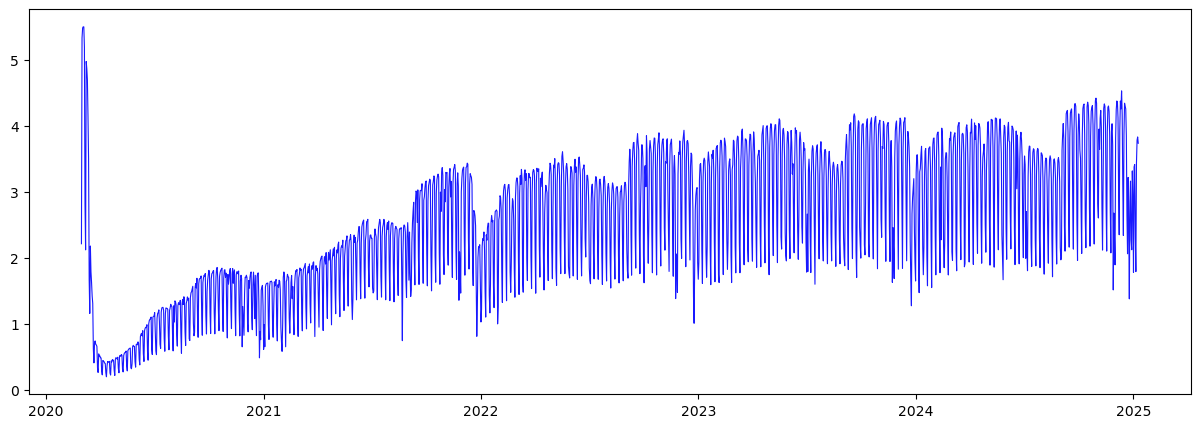

In [19]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot (df['date'], df['subway_ridership']/1e6, label='Daily Ridership', color='blue', linewidth = 0.8, alpha = 0.9)

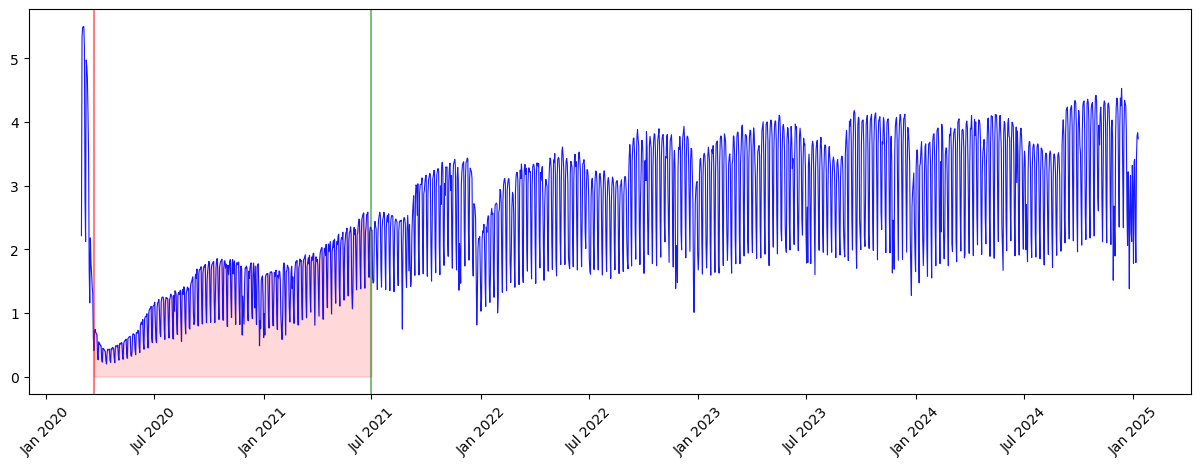

In [20]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot (df['date'], df['subway_ridership']/1e6, label='Daily Ridership', color='blue', linewidth = 0.8, alpha = 0.9)
covid_mask = df['is_covid']==1
ax.fill_between (df['date'], 0, df ['subway_ridership']/1e6, where = covid_mask, color = 'Red', alpha = 0.15, label = 'COVID PERIOD (is_covid=1)')
ax.axvline (COVID_START, color = 'Red', alpha = 0.5, linewidth = 1.5, label = 'COVID Start')
ax.axvline (COVID_END, color = 'Green', alpha = 0.5, linewidth = 1.5, label = 'COVID End')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.savefig('../Reports/02_covid_flag.png', dpi=150, bbox_inches='tight')

In [21]:
df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
df['day_of_week'] = df['date'].dt.dayofweek
df['day_of_week_name'] = df['date'].dt.day_name()

In [22]:
print ('Weekend flag created')
print (f'Weekend Days: {df["is_weekend"].sum()}')
print (f'Weekday Days: {(df["is_weekend"] == 0).sum()}')

Weekend flag created
Weekend Days: 507
Weekday Days: 1269


In [23]:
try:
    import holidays
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "holidays", "-q"])
    import holidays

#had to restart the kernel after installing holidays package to get it to work.

In [24]:
us_holidays = holidays.US(years=range(2020, 2026))

In [25]:
df['is_holiday'] = df['date'].apply(lambda x: 1 if x in us_holidays else 0)
holiday_dates = df[df['is_holiday'] == 1][['date', 'subway_ridership']].copy()
holiday_dates['holiday_name'] = holiday_dates['date'].apply(lambda x: us_holidays.get(x))
holiday_dates['year']         = holiday_dates['date'].dt.year

In [26]:
print("Holiday flag created")
print(f"   Total holiday days flagged: {df['is_holiday'].sum()}")
print()
print("   Holidays captured (sample — 2020 & 2021):")
print(holiday_dates[holiday_dates['year'].isin([2020, 2021])][
    ['date', 'holiday_name', 'subway_ridership']
].to_string(index=False))

Holiday flag created
   Total holiday days flagged: 61

   Holidays captured (sample — 2020 & 2021):
      date                                    holiday_name  subway_ridership
2020-05-25                                    Memorial Day            393918
2020-07-03                     Independence Day (observed)            851877
2020-07-04                                Independence Day            591605
2020-09-07                                       Labor Day            870964
2020-10-12                                    Columbus Day           1284655
2020-11-11                                    Veterans Day           1614812
2020-11-26                                Thanksgiving Day            652276
2020-12-25                                   Christmas Day            485208
2021-01-01                                  New Year's Day            613692
2021-01-18                      Martin Luther King Jr. Day           1276978
2021-02-15                           Washington's Bi

In [27]:
print ('Average subway ridership by day of week (2020-2025)')

avg_weekday = df[df['is_weekend']==0]['subway_ridership'].mean()
avg_weekend = df[df['is_weekend']==1]['subway_ridership'].mean()
avg_holiday = df[df['is_holiday']==1]['subway_ridership'].mean()
avg_normal = df[(df['is_weekend']==0) & (df['is_holiday']==0)]['subway_ridership'].mean()

print (f'Normal Weekday Average Ridership : {avg_weekday:>12,.0f}')
print (f'Weekend Average Ridership : {avg_weekend:>12,.0f}({(avg_weekend/avg_weekday-1)*100:+.1f}% vs weekday)')
print (f'Holiday Average Ridership : {avg_holiday:>12,.0f}({(avg_holiday/avg_weekday-1)*100:+.1f}% vs weekday)')
print (f'Normal Average Ridership : {avg_normal:>12,.0f}')

Average subway ridership by day of week (2020-2025)
Normal Weekday Average Ridership :    2,875,985
Weekend Average Ridership :    1,705,455(-40.7% vs weekday)
Holiday Average Ridership :    1,773,172(-38.3% vs weekday)
Normal Average Ridership :    2,920,413


In [28]:
import matplotlib.dates as mdates

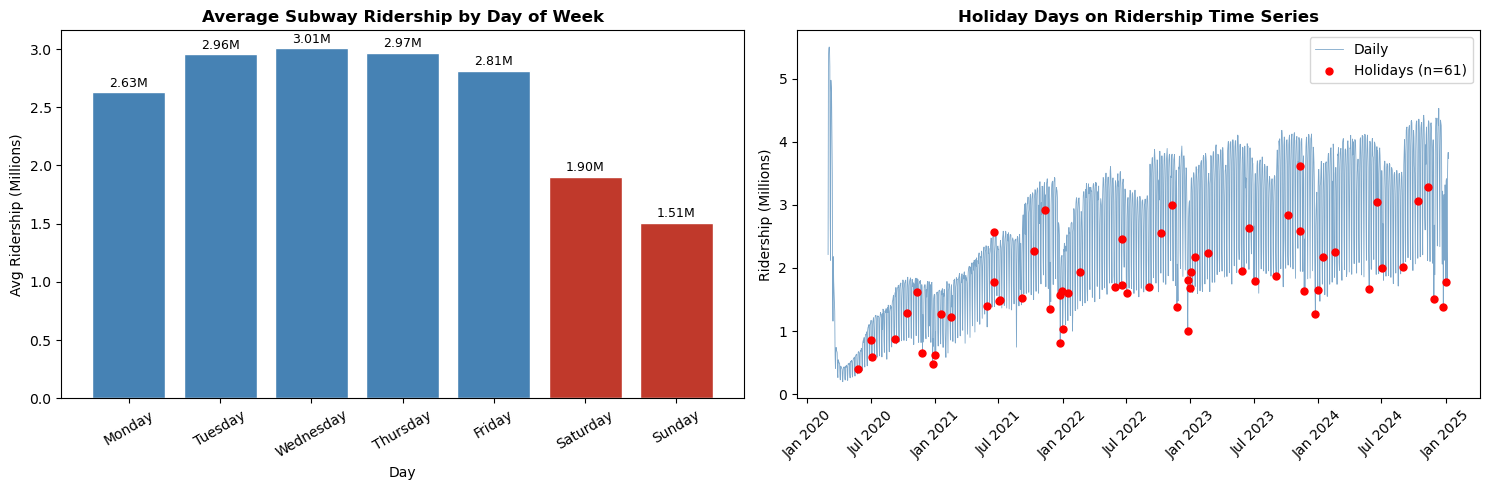

Saved to Reports


In [29]:
df['day_name'] = df['date'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
avg_by_day = df.groupby('day_name')['subway_ridership'].mean().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Bar chart by day of week
colors = ['#c0392b' if d in ['Saturday','Sunday'] else 'steelblue' for d in day_order]
bars = axes[0].bar(day_order, avg_by_day/1e6, color=colors, edgecolor='white')
axes[0].set_title("Average Subway Ridership by Day of Week", fontweight='bold')
axes[0].set_ylabel("Avg Ridership (Millions)")
axes[0].set_xlabel("Day")
for bar, val in zip(bars, avg_by_day/1e6):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}M', ha='center', va='bottom', fontsize=9)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# Plot 2: Holiday scatter on time series
axes[1].plot(df['date'], df['subway_ridership']/1e6,
             color='steelblue', linewidth=0.6, alpha=0.7, label='Daily')
axes[1].scatter(df[df['is_holiday']==1]['date'],
                df[df['is_holiday']==1]['subway_ridership']/1e6,
                color='red', zorder=5, s=25,
                label=f"Holidays (n={df['is_holiday'].sum()})")
axes[1].set_title("Holiday Days on Ridership Time Series", fontweight='bold')
axes[1].set_ylabel("Ridership (Millions)")
axes[1].legend(fontsize=10)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../Reports/02_weekend_holiday_flags.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Reports")

In [30]:
TARGET = 'subway_ridership'

Q1 = df[TARGET].quantile(0.25)
Q3 = df[TARGET].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

df ['is_outlier'] = ((df[TARGET] < lower_fence) | (df[TARGET] > upper_fence)).astype(int)

print("  OUTLIER DETECTION REPORT — IQR METHOD")
print("=" * 55)
print(f"  Q1 (25th pct)  : {Q1:>12,.0f}")
print(f"  Q3 (75th pct)  : {Q3:>12,.0f}")
print(f"  IQR            : {IQR:>12,.0f}")
print(f"  Lower Fence    : {lower_fence:>12,.0f}")
print(f"  Upper Fence    : {upper_fence:>12,.0f}")
print(f"  Outliers Found : {df['is_outlier'].sum()}")
print(f"  Outlier Rate   : {df['is_outlier'].mean()*100:.2f}%")
print("=" * 55)

  OUTLIER DETECTION REPORT — IQR METHOD
  Q1 (25th pct)  :    1,735,692
  Q3 (75th pct)  :    3,476,191
  IQR            :    1,740,499
  Lower Fence    :     -875,056
  Upper Fence    :    6,086,939
  Outliers Found : 0
  Outlier Rate   : 0.00%


In [32]:
outlier_df = df[df['is_outlier']==1][['date', TARGET, 'is_covid', 'is_weekend', 'is_holiday']].copy()
outlier_df = outlier_df.sort_values(by=TARGET)

print(f"OUTLIER DAYS — Full List ({len(outlier_df)} days)")
print("-" * 70)
print(outlier_df.to_string(index=False))

print(f"\n💡 OBSERVATION:")
print(f"  COVID outliers  : {outlier_df['is_covid'].sum()}")
print(f"  Weekend outliers: {outlier_df['is_weekend'].sum()}")
print(f"  Holiday outliers: {outlier_df['is_holiday'].sum()}")
print(f"  Unexplained     : {(outlier_df[['is_covid','is_weekend','is_holiday']].sum(axis=1)==0).sum()}")

OUTLIER DAYS — Full List (0 days)
----------------------------------------------------------------------
Empty DataFrame
Columns: [date, subway_ridership, is_covid, is_weekend, is_holiday]
Index: []

💡 OBSERVATION:
  COVID outliers  : 0
  Weekend outliers: 0
  Holiday outliers: 0
  Unexplained     : 0


In [33]:
import matplotlib.dates as mdates

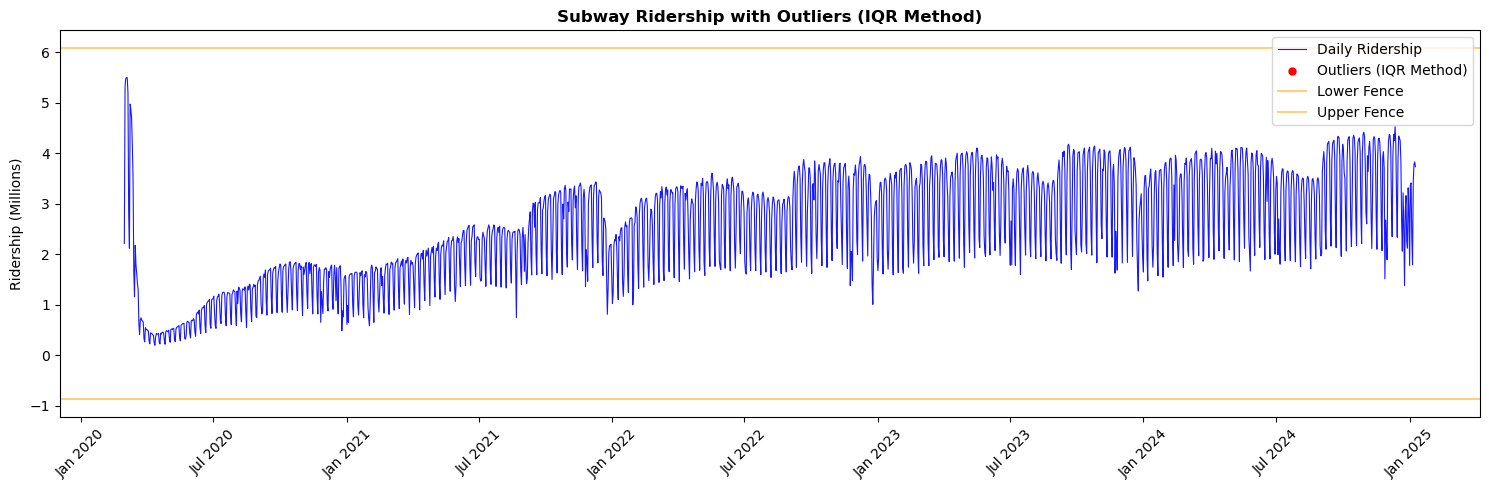

In [34]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot (df['date'], df[TARGET]/1e6, label='Daily Ridership', color='blue', linewidth = 0.8, alpha = 0.9)
ax.scatter (outlier_df['date'], outlier_df[TARGET]/1e6, color='red', s=25, label='Outliers (IQR Method)', zorder=5)

ax.axhline (lower_fence/1e6, color = 'orange', alpha = 0.5, linewidth = 1.5, label = 'Lower Fence')
ax.axhline (upper_fence/1e6, color = 'orange', alpha = 0.5, linewidth = 1.5, label = 'Upper Fence')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax.set_title("Subway Ridership with Outliers (IQR Method)", fontweight='bold')
ax.set_ylabel("Ridership (Millions)")
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../Reports/02_outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
print ('Data Integrity Report - POST CLEANING')

print ('SHAPE')
print (f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')


print ('NULLS')
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print ("No nulls found")
else: 
    print (f"Nulls found in {null_counts[null_counts>0].count()} columns")
    print (null_counts[null_counts>0])


print ('COLUMN DTYPES')
for col in df.columns:
    print (f'   {col:<30} : {df[col].dtype}')


print ('DATA CONTINUITY')
full_range = pd.date_range(start=df['date'].min(), end=df['date'].max(), freq='D')
missing_dates = full_range.difference(df['date'])
if len (missing_dates) == 0:
    print ("No missing dates found")
else:
    print (f"Missing dates found: {len(missing_dates)}")
    print(f"     {missing_dates.strftime('%Y-%m-%d').tolist()}")


print ('FLAG COLUMNS')
flag_cols = ['is_covid', 'is_weekend', 'is_holiday', 'is_outlier']
for col in flag_cols:
    ones = df[col].sum()
    zeros = len(df) - ones
    print(f"     {col:<15}: {ones:>4} days flagged (1) | {zeros:>4} days normal (0)")


print(f"TARGET VARIABLE SANITY")
print(f"Column : subway_ridership")
print(f"Min    : {df['subway_ridership'].min():>12,.0f}")
print(f"Max    : {df['subway_ridership'].max():>12,.0f}")
print(f"Mean   : {df['subway_ridership'].mean():>12,.0f}")
print(f"Nulls  : {df['subway_ridership'].isnull().sum()}")
print(f"Negatives: {(df['subway_ridership'] < 0).sum()}")


print(f"DUPLICATE ROWS")
dupes = df.duplicated().sum()
if dupes == 0:
    print(f"No duplicate rows found")
else:
    print(f"{dupes} duplicate rows found")

print(f"\n{'=' * 60}")



Data Integrity Report - POST CLEANING
SHAPE
Rows: 1,776 | Columns: 22
NULLS
No nulls found
COLUMN DTYPES
   date                           : datetime64[ns]
   subway_ridership               : int64
   subway_pct_baseline            : float64
   bus_ridership                  : int64
   bus_pct_baseline               : float64
   lirr_ridership                 : int64
   lirr_pct_baseline              : float64
   metro_north_ridership          : int64
   metro_north_pct_baseline       : float64
   access_ride_trips              : int64
   access_ride_pct_baseline       : float64
   bridges_tunnels_traffic        : int64
   bridges_tunnels_pct_baseline   : float64
   staten_island_ridership        : int64
   staten_island_pct_baseline     : float64
   is_covid                       : int64
   is_weekend                     : int64
   day_of_week                    : int32
   day_of_week_name               : object
   is_holiday                     : int64
   day_name                    

In [39]:
print (df.columns.tolist())

['date', 'subway_ridership', 'subway_pct_baseline', 'bus_ridership', 'bus_pct_baseline', 'lirr_ridership', 'lirr_pct_baseline', 'metro_north_ridership', 'metro_north_pct_baseline', 'access_ride_trips', 'access_ride_pct_baseline', 'bridges_tunnels_traffic', 'bridges_tunnels_pct_baseline', 'staten_island_ridership', 'staten_island_pct_baseline', 'is_covid', 'is_weekend', 'day_of_week', 'is_holiday', 'day_name', 'is_outlier']


In [40]:
# Recalculate IQR on non-COVID days only
normal_days = df[df['is_covid'] == 0]['subway_ridership']

Q1  = normal_days.quantile(0.25)
Q3  = normal_days.quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

df['is_outlier'] = (
    (df['subway_ridership'] < lower_fence) |
    (df['subway_ridership'] > upper_fence)
).astype(int)

print(f"  Lower Fence : {lower_fence:,.0f}")
print(f"  Upper Fence : {upper_fence:,.0f}")
print(f"  Outliers    : {df['is_outlier'].sum()}")

  Lower Fence : 211,684
  Upper Fence : 5,696,556
  Outliers    : 1


In [41]:
# See the one outlier
print("The flagged day:")
print(df[df['is_outlier']==1][['date', 'subway_ridership', 'is_covid', 'is_weekend', 'is_holiday']])

print(f"\nNon-COVID ridership distribution:")
normal = df[df['is_covid']==0]['subway_ridership']
print(f"  Min    : {normal.min():>12,.0f}")
print(f"  Max    : {normal.max():>12,.0f}")
print(f"  Mean   : {normal.mean():>12,.0f}")
print(f"  Median : {normal.median():>12,.0f}")
print(f"  Std    : {normal.std():>12,.0f}")
print(f"  Q1     : {normal.quantile(0.25):>12,.0f}")
print(f"  Q3     : {normal.quantile(0.75):>12,.0f}")

The flagged day:
         date  subway_ridership  is_covid  is_weekend  is_holiday
42 2020-04-12            198399         1           1           0

Non-COVID ridership distribution:
  Min    :      619,618
  Max    :    5,498,809
  Mean   :    2,980,790
  Median :    3,175,784
  Std    :      831,667
  Q1     :    2,268,511
  Q3     :    3,639,729


In [43]:
print("OUTLIER SUMMARY — FINAL")
print(f"  Method         : IQR on non-COVID days only")
print(f"  Lower Fence    : {lower_fence:,.0f}")
print(f"  Upper Fence    : {upper_fence:,.0f}")
print(f"  Outliers Found : {df['is_outlier'].sum()}")
print()
print("  Flagged Day:")
print(f"  Date     : 2020-04-12 (Easter Sunday)")
print(f"  Ridership: 198,399")
print(f"  Context  : COVID lockdown + weekend = extreme low")
print()
print("  NOTE: Post-COVID ridership is stable (619K–5.5M range)")
print("  IQR fences correctly contain the normal operating range.")


OUTLIER SUMMARY — FINAL
  Method         : IQR on non-COVID days only
  Lower Fence    : 211,684
  Upper Fence    : 5,696,556
  Outliers Found : 1

  Flagged Day:
  Date     : 2020-04-12 (Easter Sunday)
  Ridership: 198,399
  Context  : COVID lockdown + weekend = extreme low

  NOTE: Post-COVID ridership is stable (619K–5.5M range)
  IQR fences correctly contain the normal operating range.


In [44]:
import os

In [45]:
os.makedirs('../Data/Cleaned', exist_ok=True)

saved_path = '../Data/Cleaned/mta_ridership_cleaned.csv'

df.to_csv(saved_path, index=False)

print ('DATASET SAVED SUCCESSFULLY')
print (f"Saved to: {saved_path}")
print (f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
print (f'Size: {os.path.getsize(saved_path)/1024:.2f} KB')

DATASET SAVED SUCCESSFULLY
Saved to: ../Data/Cleaned/mta_ridership_cleaned.csv
Rows: 1,776 | Columns: 21
Size: 194.71 KB


In [46]:
df_verify = pd.read_csv(saved_path, parse_dates=['date'])

print("SAVE VERIFICATION")
print(f"  Reloaded shape  : {df_verify.shape[0]:,} rows x {df_verify.shape[1]} columns")
print(f"  Matches original: {df_verify.shape == df.shape}")
print(f"  Nulls           : {df_verify.isnull().sum().sum()}")
print(f"  Date range      : {df_verify['date'].min().strftime('%d %b %Y')} -> {df_verify['date'].max().strftime('%d %b %Y')}")
print()
print("  Clean dataset verified and ready")

SAVE VERIFICATION
  Reloaded shape  : 1,776 rows x 21 columns
  Matches original: True
  Nulls           : 0
  Date range      : 01 Mar 2020 -> 09 Jan 2025

  Clean dataset verified and ready
